# *K-NN: K-Nearest Neighbors Regressor (KNN Regressor)*

## 1. Carga de Datos

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from dotenv import load_dotenv
import os
import joblib
from pathlib import Path
import requests

Configuración para que se cree en la carpeta models en la raiz

In [64]:
carpeta_notebooks = Path.cwd()
raiz_proyecto = carpeta_notebooks.parent
carpeta_models = raiz_proyecto / "models"
carpeta_models.mkdir(parents=True, exist_ok=True)

#print(f"📁 Raíz detectada: {raiz_proyecto}")
#print(f"💾 Carpeta de destino del modelo: {carpeta_models}\n")

Carga desde la Api

In [65]:
load_dotenv()
URL_BACKEND_PLAYERS = os.getenv('URL_BACKEND_PLAYERS')

In [66]:
def get_players():
    try:
        response = requests.get(URL_BACKEND_PLAYERS)
        if response.status_code == 200:
            return response.json()
        else:
            print(f'Error al obtener los jugadores: {response.status_code} - {response.text}')
            return None
    except Exception as e:
        print(f'Error con la conexión a la API de jugadores: {e}')
        return None

In [67]:
df = pd.DataFrame(get_players())
print("Datos cargados exitosamente")

Datos cargados exitosamente


In [68]:
df = df.drop(columns=['name'])

## 2. Preparación de los datos

### Variables de Entrada y Objetivo (X e Y)

In [69]:
columnas = ['age', 'height_in_cm', 'position','club_name','league_id','country_of_birth','last_season']
X = df[columnas]
y = df['market_value_in_eur']

## 3. Pipeline de Prepocesamiento (Conversión a números y escalado)

### Transformador de Columnas (Categóricas y Escalado)

Creamos el preprocesador que tratará cada columna de manera independiente:

* Las numéricas se estandarizan (StandardScaler)

* Las categóricas se convierten a binarias/numéricas (OneHotEncoder)

In [70]:
columnas_numericas = ['age', 'height_in_cm','last_season']
columnas_categoricas = ['position','club_name','league_id','country_of_birth']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas),
        
    ],
    #Dejamos las columnas numéricas sin cambios
    remainder='passthrough'
)

## 4. Configuración de K-FOLD CROSS-VALIDATION

In [71]:
print("\n🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...")


🚀 Iniciando K-Fold Cross-Validation con métricas de error (MAE, MSE, RMSE)...


In [72]:
# Usamos 5 bloques (Folds). shuffle=True mezcla aleatoriamente los datos antes de separar
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 5. Optimización de Hiperparámetros y Entrenamiento del Pipeline K-NN

In [73]:
# Instanciamos el regresor KNN
knn_model = KNeighborsRegressor(n_jobs=-1)

In [74]:
# Unificamos el preprocesamiento y el modelo dentro del Pipeline definitivo
pipeline_knn = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('scaler', StandardScaler()),  # Escalamos después de OneHotEncoder para evitar distorsiones
    ('modelo', knn_model)
])

In [75]:
#Definimos la matriz de parámetros que queremos evaluar
# Evaluamos diferentes vecinos, funciones de peso y métricas de distancia
param_grid = {
    'modelo__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'modelo__weights': ['uniform', 'distance'],
    'modelo__p': [1, 2]  # 1: Distancia Manhattan, 2: Distancia Euclidiana
}

print("🔎 Iniciando búsqueda del mejor modelo mediante GridSearchCV...")

🔎 Iniciando búsqueda del mejor modelo mediante GridSearchCV...


In [76]:
# Configuramos el GridSearch usando tu estrategia de K-Fold (kf) ya declarada
grid_search = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [77]:
# --- DIVISIÓN DE CONTROL DE OVERFITTING Y EVALUACIÓN DE RESIDUOS ---
# Usamos un 20% para validación de métricas directas y gráficos, manteniendo el random_state=42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
# Ejecutamos la optimización utilizando únicamente el conjunto de Entrenamiento
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__n_neighbors': [3, 5, ...], 'modelo__p': [1, 2], 'modelo__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto

In [79]:
# Extraemos el mejor Pipeline optimizado encontrado
pipeline_knn_best = grid_search.best_estimator_

print("\n🏆 ¡Optimización Completada!")
print(f"   Mejores Hiperparámetros encontrados: {grid_search.best_params_}")
print(f"   Mejor puntuación R² en Entrenamiento Cruzado: {grid_search.best_score_:.4f}")


🏆 ¡Optimización Completada!
   Mejores Hiperparámetros encontrados: {'modelo__n_neighbors': 15, 'modelo__p': 1, 'modelo__weights': 'distance'}
   Mejor puntuación R² en Entrenamiento Cruzado: 0.2828


In [80]:
# Predicciones con el modelo ya optimizado para evaluar sobreajuste
y_pred_train = pipeline_knn_best.predict(X_train)
y_pred_val = pipeline_knn_best.predict(X_val)

## 6. Informe de Métricas de Regresión y Control de Overfitting (< 5%)

In [81]:
# Cálculo de métricas
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

In [82]:
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

In [83]:
# Cálculo de la diferencia porcentual de Overfitting basado en RMSE
dif_overfitting = abs(rmse_train - rmse_val) / rmse_train * 100

In [84]:
print("="*60)
print("📊 INFORME DEL RENDIMIENTO DEL MODELO OPTIMIZADO")
print("="*60)
print(f"Métrica     | Entrenamiento     | Validación")
print(f"------------|-------------------|-------------------")
print(f"RMSE (€)    | {rmse_train:<17.2f} | {rmse_val:.2f}")
print(f"MAE (€)     | {mae_train:<17.2f} | {mae_val:.2f}")
print(f"R²          | {r2_train:<17.4f} | {r2_val:.4f}")
print("-"*60)
print(f"⚠️ Diferencia de Overfitting (RMSE): {dif_overfitting:.2f}%")

📊 INFORME DEL RENDIMIENTO DEL MODELO OPTIMIZADO
Métrica     | Entrenamiento     | Validación
------------|-------------------|-------------------
RMSE (€)    | 162480.55         | 8694772.12
MAE (€)     | 5899.15           | 3155832.06
R²          | 0.9998            | 0.2359
------------------------------------------------------------
⚠️ Diferencia de Overfitting (RMSE): 5251.27%


In [85]:
if dif_overfitting <= 5:
    print("✅ ¡Éxito! El overfitting es inferior al 5%. El modelo es estable y generaliza bien.")
else:
    print("❌ Alerta: El overfitting es superior al 5%.")
    print("   El modelo óptimo seleccionado todavía presenta una diferencia notable entre train y val.")
print("="*60)

❌ Alerta: El overfitting es superior al 5%.
   El modelo óptimo seleccionado todavía presenta una diferencia notable entre train y val.


## 7. Gráficos de Análisis del Rendimiento (Predicción vs Real y Residuos)

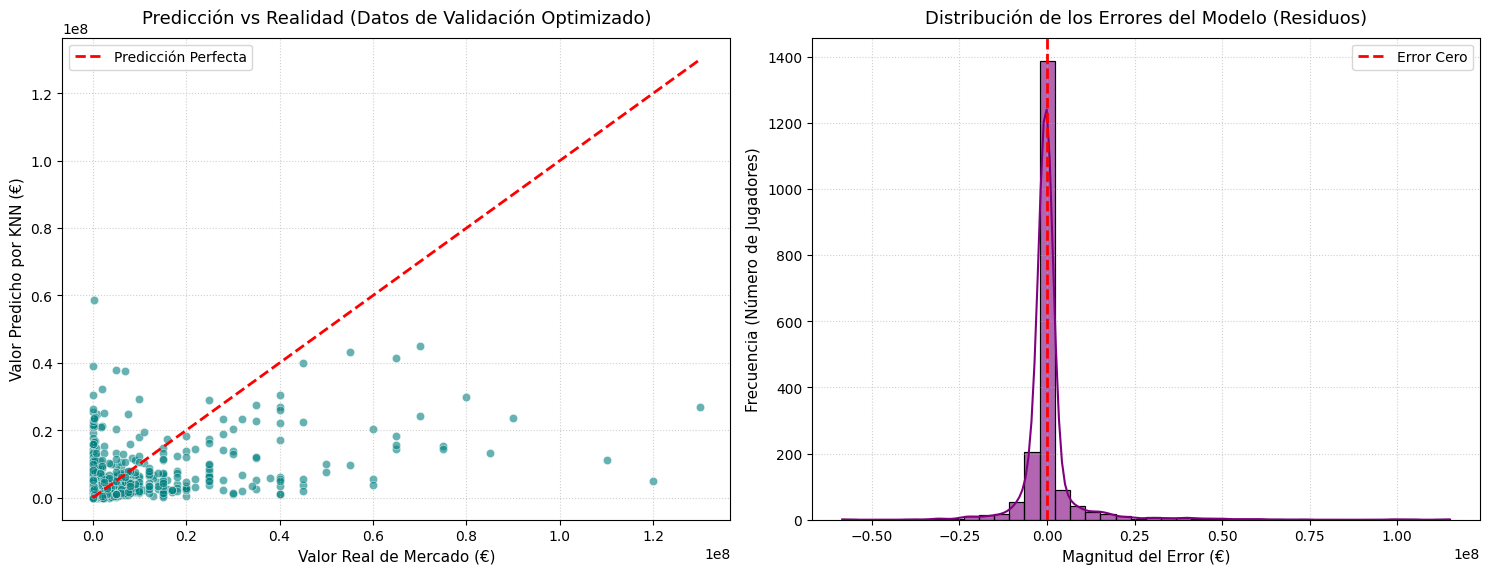

In [86]:
# Cálculo de los errores (residuos) del modelo optimizado
residuos = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Predicción vs Realidad
sns.scatterplot(x=y_val, y=y_pred_val, ax=axes[0], alpha=0.6, color='teal')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title('Predicción vs Realidad (Datos de Validación Optimizado)', fontsize=13, pad=10)
axes[0].set_xlabel('Valor Real de Mercado (€)', fontsize=11)
axes[0].set_ylabel('Valor Predicho por KNN (€)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Distribución de los Residuos
sns.histplot(residuos, kde=True, ax=axes[1], color='purple', bins=40, alpha=0.6)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')
axes[1].set_title('Distribución de los Errores del Modelo (Residuos)', fontsize=13, pad=10)
axes[1].set_xlabel('Magnitud del Error (€)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Número de Jugadores)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Feature Importance (Permutation Importance)

In [87]:
print("Calculando Feature Importance mediante Permutación...")
# Evaluamos sobre el conjunto de validación para ver la importancia real al generalizar
resultado_importancia = permutation_importance(pipeline_knn_best, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)

Calculando Feature Importance mediante Permutación...


In [88]:
# Estraemos los nombres de las variables originales de entrada
df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia_Media': resultado_importancia.importances_mean
}).sort_values(by='Importancia_Media', ascending=False)

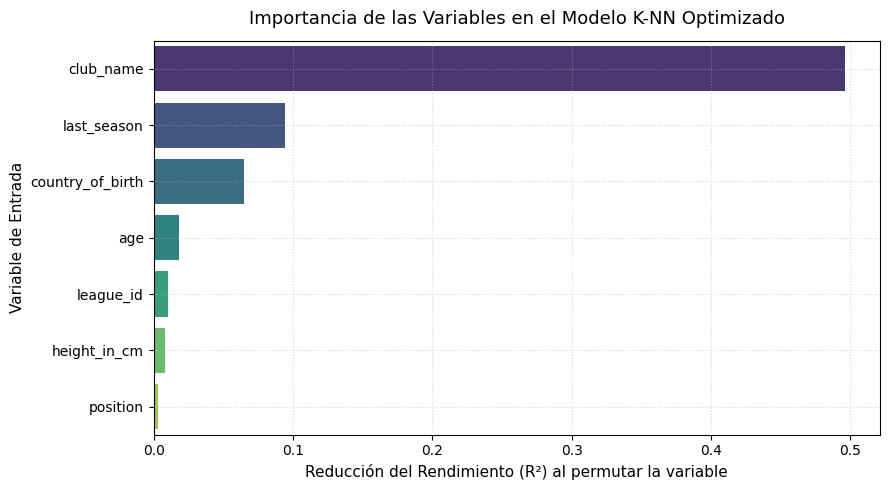

In [89]:
# Gráfico de barras de importancia
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_importancia, 
    x='Importancia_Media', 
    y='Variable', 
    hue='Variable', 
    palette='viridis', 
    legend=False
)
plt.title('Importancia de las Variables en el Modelo K-NN Optimizado', fontsize=13, pad=12)
plt.xlabel('Reducción del Rendimiento (R²) al permutar la variable', fontsize=11)
plt.ylabel('Variable de Entrada', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Almacenamiento Final del Modelo

In [90]:
# Guardamos el pipeline optimizado (.pkl) de forma segura en la raíz
filename = carpeta_models / "knn_regressor_model.pkl"
joblib.dump(pipeline_knn_best, filename)

print(f"✨ ¡Proceso completado! Modelo optimizado guardado con éxito.")
#print(f"💾 Guardado de forma absoluta en: '{filename}'")

✨ ¡Proceso completado! Modelo optimizado guardado con éxito.
